In [2]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [26]:
# LOAD DATA

urbanev_master = pd.read_csv("urbanev_master.csv")

print("Dataset Shape:")
print(urbanev_master.shape)

display(urbanev_master.head())

Dataset Shape:
(2134080, 19)


,timestamp,station_id,volume,occupancy,duration,energy_cost_per_kwh,num,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing,utilization_rate,revenue,occupancy_density,queue_proxy
0,2022-06-19 00:00:00,102,2.858333,12,0.49,0.924,1,30,3,27,0.71,114.103,22.54041,0,0,0.4,2.6411,0.4,1.143333
1,2022-06-19 00:05:00,102,4.375000,12,0.75,0.924,1,30,3,27,0.71,114.103,22.54041,0,0,0.4,4.0425,0.4,1.750000
2,2022-06-19 00:10:00,102,4.375000,12,0.75,0.924,1,30,3,27,0.71,114.103,22.54041,0,0,0.4,4.0425,0.4,1.750000
3,2022-06-19 00:15:00,102,4.375000,12,0.75,0.924,1,30,3,27,0.71,114.103,22.54041,0,0,0.4,4.0425,0.4,1.750000
4,2022-06-19 00:20:00,102,4.375000,12,0.75,0.924,1,30,3,27,0.71,114.103,22.54041,0,0,0.4,4.0425,0.4,1.750000


In [29]:
# DATETIME CONVERSION

urbanev_master['timestamp'] = pd.to_datetime(
    urbanev_master['timestamp']
)

print(
    urbanev_master['timestamp'].dtype
)

datetime64[ns]


In [30]:
# CREATE TIME FEATURES

urbanev_master['hour'] = (
    urbanev_master['timestamp']
    .dt.hour
)

urbanev_master['day_of_week'] = (
    urbanev_master['timestamp']
    .dt.dayofweek
)

urbanev_master['month'] = (
    urbanev_master['timestamp']
    .dt.month
)

urbanev_master['weekend'] = (
    urbanev_master['day_of_week']
    .isin([5,6])
    .astype(int)
)

print("\nTime Features Created")



Time Features Created


In [40]:
# SELECT FEATURES

features = [
    'hour',
    'day_of_week',
    'month',
    'weekend',
    'occupancy',
    'duration',
    'count',
    'fast_count',
    'slow_count',
    'CBD',
    'dynamic_pricing'
]

target = 'volume'

print("\nFeatures Used:")
print(features)


Features Used:
['hour', 'day_of_week', 'month', 'weekend', 'occupancy', 'duration', 'count', 'fast_count', 'slow_count', 'CBD', 'dynamic_pricing']


In [41]:
# CHECK FOR MISSING VALUES

print("\nMissing Values:")

print(
    urbanev_master[
        features + [target]
    ].isnull().sum()
)


Missing Values:
hour               0
day_of_week        0
month              0
weekend            0
occupancy          0
duration           0
count              0
fast_count         0
slow_count         0
CBD                0
dynamic_pricing    0
volume             0
dtype: int64


In [42]:
# REMOVE MISSING ROWS IF ANY

model_df = urbanev_master[
    features + [target] + ['timestamp']
].dropna()

print("\nShape After Cleaning:")
print(model_df.shape)


Shape After Cleaning:
(2134080, 13)


In [43]:
# TIME-BASED TRAIN TEST SPLIT

model_df = model_df.sort_values(
    'timestamp'
)

split_idx = int(
    len(model_df) * 0.80
)

train = model_df.iloc[:split_idx]
test = model_df.iloc[split_idx:]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("\nTrain Shape:", train.shape)
print("Test Shape :", test.shape)


Train Shape: (1707264, 13)
Test Shape : (426816, 13)


In [44]:
# TRAIN RANDOM FOREST MODEL

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

print("\nModel Training Complete")


Model Training Complete


In [45]:
# MAKE PREDICTIONS

preds = rf.predict(X_test)

print("\nPredictions Generated")


Predictions Generated


In [46]:
# EVALUATION METRICS

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print("\n")
print("="*50)
print("DEMAND PREDICTION RESULTS")
print("="*50)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

print("="*50)



DEMAND PREDICTION RESULTS
MAE  : 4.2523
RMSE : 13.7748
R²   : 0.9836


In [47]:
# FEATURE IMPORTANCE

importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
})

importance = (
    importance
    .sort_values(
        'Importance',
        ascending=False
    )
)

print("\nTop Features:")

display(importance)


Top Features:


,Feature,Importance
7,fast_count,0.623575
5,duration,0.207942
8,slow_count,0.098411
6,count,0.026408
0,hour,0.025100
4,occupancy,0.013213
10,dynamic_pricing,0.003098
1,day_of_week,0.000932
9,CBD,0.000572
2,month,0.000437


In [48]:
# PREDICTIONS

preds = rf.predict(
    test[features]
)

preds[:10]

array([  8.36683033,   7.27332917,   7.28407099,   7.28407099,
        25.93758445,   5.62756543,   6.73122003,   0.58177443,
         7.22976104, 253.89222291])

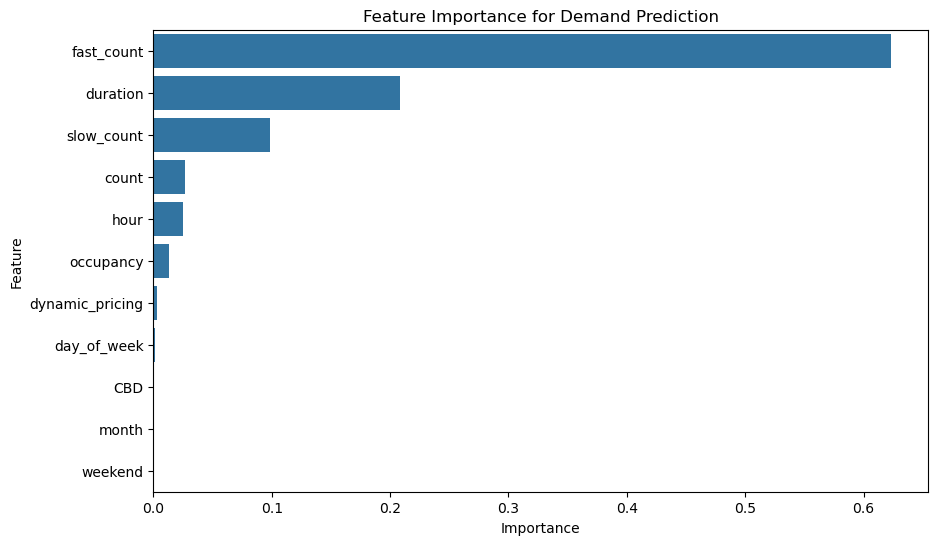

In [49]:
# FEATURE IMPORTANCE PLOT

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Feature Importance for Demand Prediction'
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.show()

In [50]:
# =====================================================
# 16. ACTUAL VS PREDICTED
# =====================================================

comparison = pd.DataFrame({
    'Actual':test[target].values,
    'Predicted':preds
})

comparison.head()

,Actual,Predicted
0,8.166667,8.366830
1,7.583333,7.273329
2,7.583333,7.284071
3,7.583333,7.284071
4,24.916667,25.937584


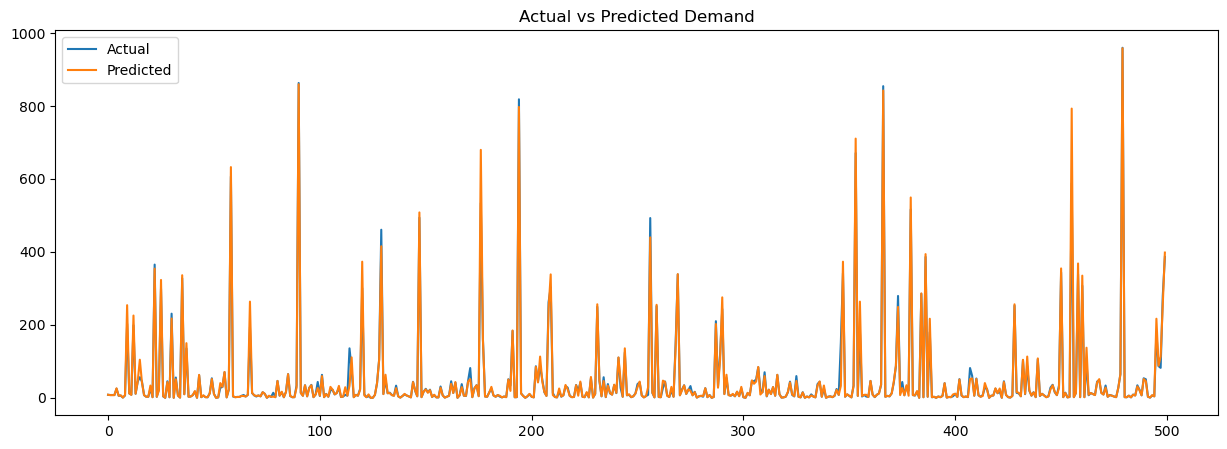

In [51]:
# =====================================================
# 17. VISUALIZE PREDICTIONS
# =====================================================

sample = comparison.iloc[:500]

plt.figure(figsize=(15,5))

plt.plot(
    sample['Actual'].values,
    label='Actual'
)

plt.plot(
    sample['Predicted'].values,
    label='Predicted'
)

plt.title(
    'Actual vs Predicted Demand'
)

plt.legend()

plt.show()

In [53]:
# =====================================================
# 18. ERROR ANALYSIS
# =====================================================

comparison['Error'] = (
    comparison['Actual']
    - comparison['Predicted']
)

comparison['Absolute_Error'] = (
    comparison['Error']
    .abs()
)

print(comparison['Absolute_Error'].describe())

count    426816.000000
mean          4.252281
std          13.102078
min           0.000000
25%           0.107719
50%           0.364580
75%           2.128964
max         299.142782
Name: Absolute_Error, dtype: float64


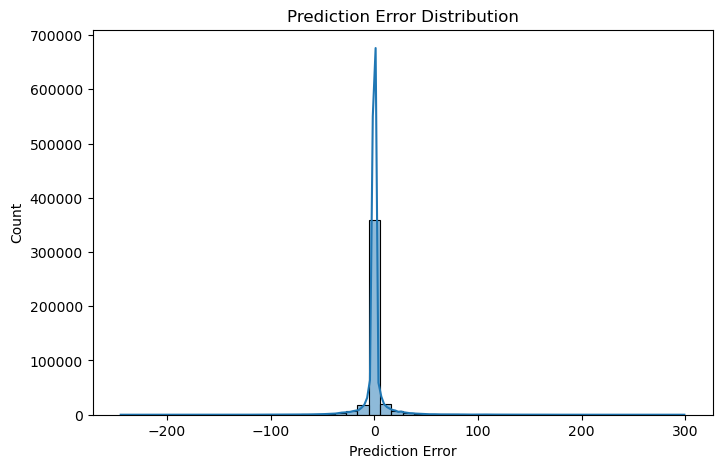

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(
    comparison['Error'],
    bins=50,
    kde=True
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.show()

# Most prediction errors are concentrated around zero, indicating that the model generally produces unbiased forecasts. Large errors primarily occur during sudden demand spikes, which are inherently harder to predict.

In [55]:
# =====================================================
# 19. EXPORT RESULTS
# =====================================================

comparison.to_csv(
    "demand_prediction_results.csv",
    index=False
)

print("Results Saved")

Results Saved


# Demand Prediction Agent Summary

## Model Performance

- MAE: 4.25
- RMSE: 13.77
- R²: 0.984

## Key Findings

1. Fast charger availability is the strongest predictor of charging demand.

2. Charging duration significantly influences energy consumption and station demand.

3. Demand exhibits clear temporal behavior, with hour-of-day effects contributing to forecasting performance.

4. Dynamic pricing and CBD location contribute less predictive power than operational station characteristics.

## Agent Output

The Demand Prediction Agent generates short-term demand forecasts that can be consumed by the Dynamic Tariff Optimization Agent to support congestion management and revenue optimization.